# 02 — Does bare RSI predict a reversal? (15m, 2024 = train)

Before touching divergence we test the simplest RSI claim retail believes:

> **RSI crossing *into* oversold (<30) → price bounces UP; crossing *into* overbought (>70) → price fades DOWN — more than a random bar would.**

### Hypothesis as a prediction (stated before running)
From the levels line we learned crypto mean-reversion lives in **move magnitude**, not in chart furniture. An RSI dip below 30 on 15m *is* a recent sharp drop, so an oversold cross ≈ "buy the dip". **Prediction:** oversold→long shows a small positive forward edge **above baseline** at short horizons (15m–2h) but likely **below the ~0.15% round-trip cost**; overbought→short is weaker or null, because alts drift up (shorting strength fights the drift). If even the long side is at/below baseline, bare RSI is a coin flip and we move to divergence.

### Discipline
- **2024 only.** All of 2025+ is reserved for OOS — we do not look at it here.
- **Pooled** across the 165-symbol full-2024 universe (one symbol = anecdote).
- **Causal entry.** The RSI cross is defined at the *close* of bar `t`; the forward return is `t → t+H` (pure future). Entering at `close[t]` uses no future info. (A 1-bar-late fill is a later robustness check.)
- **Baseline = unconditional** mean forward return over *every* bar. An event number means nothing without it.
- **Costs:** ~0.15% round-trip on alt perps; an edge below that is not real.

In [1]:
import sys; sys.path.insert(0, ".")
from _lab import *

TF = "15min"
Y0, Y1 = "2024-01-01", "2025-01-01"   # 2024 ONLY (2025 = OOS, untouched)
RSI_N, LO, HI = 14, 30, 70
HS = [1, 2, 4, 8, 16, 32, 48, 96]      # forward horizons in 15m bars (15m .. 24h)

uni = [s for s in list_symbols() if coverage(s)[0] <= "2024-01" and coverage(s)[1] >= "2024-12"]
print(f"universe: {len(uni)} symbols | TF={TF} | {Y0}..{Y1} | RSI({RSI_N}) bands {LO}/{HI}")

universe: 165 symbols | TF=15min | 2024-01-01..2025-01-01 | RSI(14) bands 30/70


In [2]:
import numpy as np

def collect():
    # Pooled per-horizon: event forward returns (lists) + baseline sums/counts.
    os_ret = {h: [] for h in HS}   # oversold-cross forward returns (long view)
    ob_ret = {h: [] for h in HS}   # overbought-cross forward returns (short view = -ret)
    base_sum = {h: 0.0 for h in HS}; base_n = {h: 0 for h in HS}
    n_os = n_ob = 0
    for j, s in enumerate(uni):
        try:
            d = ohlcv(s, Y0, Y1, TF)
        except Exception:
            continue
        if len(d) < 200:
            continue
        c = d["close"].to_numpy()
        r = rsi(d["close"], RSI_N).to_numpy()
        os_ev = np.where((r[:-1] >= LO) & (r[1:] < LO))[0] + 1   # cross DOWN into <30
        ob_ev = np.where((r[:-1] <= HI) & (r[1:] > HI))[0] + 1   # cross UP into >70
        n_os += len(os_ev); n_ob += len(ob_ev)
        for h in HS:
            fr = c[h:] / c[:-h] - 1.0           # forward return at horizon h, aligned to bar t
            base_sum[h] += fr.sum(); base_n[h] += len(fr)
            m = len(fr)
            oe = os_ev[os_ev < m]; be = ob_ev[ob_ev < m]
            os_ret[h].extend(fr[oe].tolist())
            ob_ret[h].extend(fr[be].tolist())
        if (j + 1) % 40 == 0:
            print(f"  {j+1}/{len(uni)} done")
    base = {h: base_sum[h] / base_n[h] for h in HS}
    return os_ret, ob_ret, base, n_os, n_ob

os_ret, ob_ret, base, n_os, n_ob = collect()
print(f"\noversold crosses: {n_os:,} | overbought crosses: {n_ob:,}")

  40/165 done


  80/165 done


  120/165 done


  160/165 done



oversold crosses: 73,508 | overbought crosses: 71,076


## Read-out tables

For each horizon we report the **directional PnL** of the trade (long for oversold, short for overbought = `-forward_ret`), next to the baseline a random entry would earn in the same direction. `edge = mean − baseline`. `net = edge − 0.15%` cost. We trust **mean/std** (per-trade Sharpe-like) and the **edge vs baseline**, not win% alone.

In [3]:
COST = 0.0015
def tbl(ret, base, sign, title):
    rows = []
    for h in HS:
        a = np.asarray(ret[h]) * sign          # directional PnL
        b = base[h] * sign                      # baseline in same direction
        rows.append(dict(h=h, n=len(a),
                         mean_pct=round(a.mean()*100, 3),
                         median_pct=round(np.median(a)*100, 3),
                         win_pct=round((a > 0).mean()*100, 1),
                         mean_std=round(a.mean()/a.std(), 4),
                         base_pct=round(b*100, 3),
                         edge_pct=round((a.mean()-b)*100, 3),
                         net_pct=round((a.mean()-b-COST)*100, 3)))
    df = pd.DataFrame(rows).set_index("h")
    print(f"\n=== {title} ===")
    print(df.to_string())
    return df

t_os = tbl(os_ret, base, +1.0, "OVERSOLD cross (<30)  ->  LONG")
t_ob = tbl(ob_ret, base, -1.0, "OVERBOUGHT cross (>70)  ->  SHORT")


=== OVERSOLD cross (<30)  ->  LONG ===
        n  mean_pct  median_pct  win_pct  mean_std  base_pct  edge_pct  net_pct
h                                                                              
1   73508     0.021       0.093     56.2    0.0181     0.002     0.019   -0.131
2   73501     0.077       0.141     57.5    0.0565     0.004     0.073   -0.077
4   73501     0.099       0.170     56.9    0.0553     0.008     0.091   -0.059
8   73467     0.129       0.180     55.8    0.0583     0.016     0.113   -0.037
16  73462     0.207       0.242     55.8    0.0687     0.031     0.176    0.026
32  73422     0.329       0.289     55.2    0.0905     0.061     0.267    0.117
48  73422     0.447       0.335     54.8    0.1012     0.091     0.356    0.206
96  73298     0.440       0.348     53.2    0.0706     0.176     0.264    0.114

=== OVERBOUGHT cross (>70)  ->  SHORT ===
        n  mean_pct  median_pct  win_pct  mean_std  base_pct  edge_pct  net_pct
h                                    

## The event-study curve

Mean directional PnL vs horizon — **event (solid) vs baseline (dashed)**. If RSI has edge, the solid line sits clearly above its dashed baseline AND above the dotted cost line. Left = oversold→long, right = overbought→short.

[saved] notebooks\rsi\_out\02_rsi_eventstudy.png


WindowsPath('C:/projects/researchlab/notebooks/rsi/_out/02_rsi_eventstudy.png')

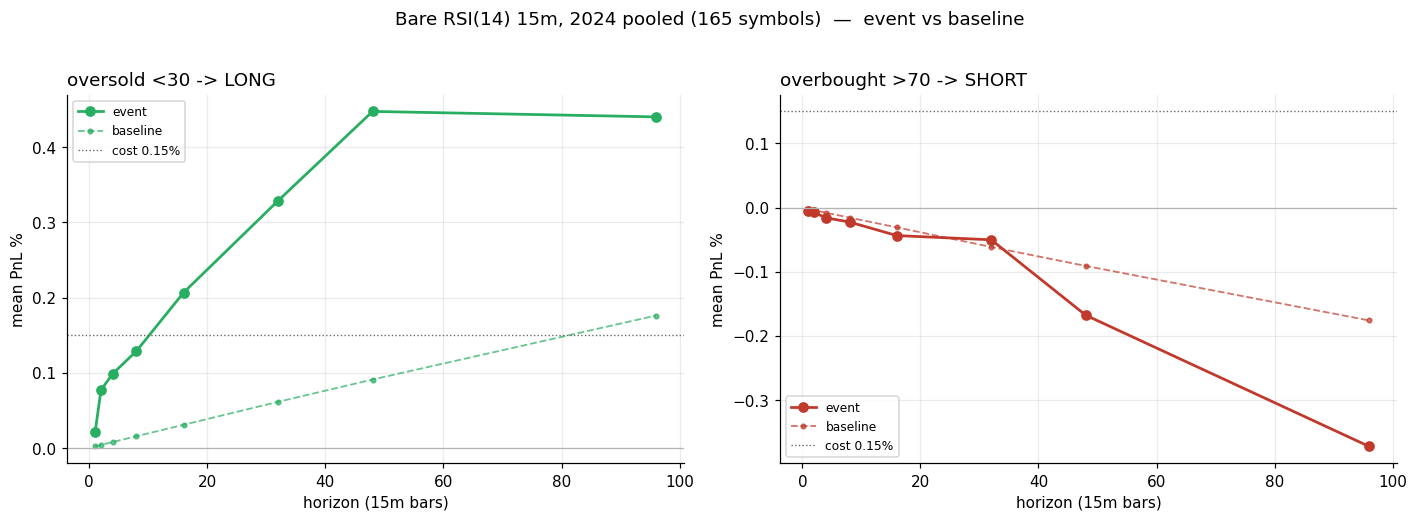

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for ax, (ret, sign, ttl, col) in zip(axes, [
        (os_ret, +1.0, "oversold <30 -> LONG", "#27ae60"),
        (ob_ret, -1.0, "overbought >70 -> SHORT", "#c0392b")]):
    ev = [np.asarray(ret[h]).mean()*sign*100 for h in HS]
    bl = [base[h]*sign*100 for h in HS]
    ax.plot(HS, ev, marker="o", color=col, lw=1.8, label="event")
    ax.plot(HS, bl, marker=".", color=col, lw=1.2, ls="--", alpha=0.7, label="baseline")
    ax.axhline(0.15, color="0.4", lw=0.9, ls=":", label="cost 0.15%")
    ax.axhline(0, color="0.7", lw=0.8)
    ax.set_xlabel("horizon (15m bars)"); ax.set_ylabel("mean PnL %")
    ax.set_title(ttl, loc="left"); ax.legend(fontsize=8)
fig.suptitle(f"Bare RSI(14) 15m, 2024 pooled ({len(uni)} symbols)  —  event vs baseline", y=1.02)
show("02_rsi_eventstudy")

## Verdict & caveats

**FIRST NON-NULL — and it's asymmetric.**

- **OVERSOLD<30 → LONG works.** Forward PnL sits above its baseline at *every*
  horizon and the gap grows monotonically. After 0.15% cost it goes net-positive
  from ~4h on (h16 +0.03%, h32 +0.12%, h48 +0.21%, h96 +0.11%), mean/std ≈ 0.10
  @ h48. A real above-drift dip-buy effect.
- **OVERBOUGHT>70 → SHORT loses.** Mean short PnL is negative and gets worse with
  horizon (−0.37% @ 12h); edge vs baseline ≤ 0; net deeply negative. Note the
  **win-rate trap**: median short PnL is *positive* (most shorts make a little)
  while the mean is negative — rare violent up-runners eat the book. Shorting
  strength on up-drifting alts is a short-vol loser.

**So RSI is a dip-BUY signal, not a sell signal, on 2024 alts.** The folklore
"70 = sell" is refuted here; "30 = buy" survives, at multi-hour horizons.

**Uncontrolled so far:** overlapping forward windows (autocorrelated → effective
n < shown n); entry exactly at `close[t]` (optimistic vs 1-bar-late fill); flat
0.15% cost; 2024 only (one regime, train); no per-symbol vol normalization;
funding ignored; **and the big one — oversold ≈ "a recent sharp drop", so this
may just be generic magnitude dip-buying (see levels line). nb03 must control RSI
against a plain N-bar % drop to see if RSI adds anything.** 2025 stays sealed.